In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO MULTIPLE QUOTE CUSTOMERS
print("\n🎯 FILTERING TO MULTIPLE QUOTE CUSTOMERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])


🎯 FILTERING TO MULTIPLE QUOTE CUSTOMERS


In [3]:
# ANALYSIS: What predicts high engagement from first quote?
print("\n=== PREDICTING HIGH ENGAGEMENT FROM FIRST QUOTE ===\n")

# Get first quote for each customer
first_quotes = df_quotes.sort_values('dt_creation_devis').groupby('numero_compte').first().reset_index()

# Add eventual quote count
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='eventual_quote_count')
first_quotes = first_quotes.merge(quote_counts, on='numero_compte')

# Define high engagement
first_quotes['is_high_engagement'] = (first_quotes['eventual_quote_count'] >= 3).astype(int)

# Check distribution
print(f"High engagement (3+ quotes): {first_quotes['is_high_engagement'].mean():.1%} of customers")
print(f"Medium engagement (2 quotes): {(first_quotes['eventual_quote_count'] == 2).mean():.1%}")
print(f"Low engagement (1 quote): {(first_quotes['eventual_quote_count'] == 1).mean():.1%}")

# 1. By product at first quote
print("\n📊 BY PRODUCT AT FIRST QUOTE:")
prod_analysis = first_quotes.groupby('famille_equipement_produit').agg({
    'eventual_quote_count': 'mean',
    'is_high_engagement': 'mean',
    'numero_compte': 'count'
}).round(3).sort_values('is_high_engagement', ascending=False)

print(prod_analysis.to_string())

# 2. By region
print("\n📊 BY REGION:")
region_analysis = first_quotes.groupby('nom_region').agg({
    'eventual_quote_count': 'mean',
    'is_high_engagement': 'mean',
    'numero_compte': 'count'
}).round(3).sort_values('is_high_engagement', ascending=False)

print(region_analysis.to_string())

# 3. By price tier
first_quotes['price_tier'] = pd.qcut(first_quotes['mt_apres_remise_ht_devis'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
print("\n📊 BY PRICE TIER:")
price_analysis = first_quotes.groupby('price_tier').agg({
    'eventual_quote_count': 'mean',
    'is_high_engagement': 'mean',
    'numero_compte': 'count'
}).round(3)

print(price_analysis.to_string())

# 4. By subsidy amount
first_quotes['has_subsidy'] = (first_quotes['mt_prime_cee'] + first_quotes['mt_prime_maprimerenov'] > 0).astype(int)
print("\n📊 WITH vs WITHOUT SUBSIDY:")
subsidy_analysis = first_quotes.groupby('has_subsidy').agg({
    'eventual_quote_count': 'mean',
    'is_high_engagement': 'mean',
    'numero_compte': 'count'
}).round(3)

print(subsidy_analysis.to_string())


=== PREDICTING HIGH ENGAGEMENT FROM FIRST QUOTE ===

High engagement (3+ quotes): 8.3% of customers
Medium engagement (2 quotes): 22.3%
Low engagement (1 quote): 69.4%

📊 BY PRODUCT AT FIRST QUOTE:
                                  eventual_quote_count  is_high_engagement  numero_compte
famille_equipement_produit                                                               
Photovoltaïque                                   1.800               0.177            549
Autres                                           1.550               0.116            258
Pompe à chaleur                                  1.534               0.114           4575
Emetteur de chauffage  ou chappe                 1.564               0.103             78
Appareil hybride                                 1.518               0.102            137
Climatisation                                    1.531               0.099           4832
Produit VMC                                      1.429               0.086       

In [4]:
# Count quotes per customer
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='quote_count')

# Get customers with 2+ quotes
multi_quote_ids = quote_counts[quote_counts['quote_count'] >= 2]['numero_compte'].tolist()

# Filter data
df_quotes_multi = df_quotes[df_quotes['numero_compte'].isin(multi_quote_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Multiple quote customers (≥2): {len(multi_quote_ids):,}")
print(f"Quotes: {len(df_quotes_multi):,}")

# Save to file
df_quotes_multi.to_csv('cleaned_quote_data_multi.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_multi.csv")

Original customers: 25,716
Multiple quote customers (≥2): 7,858
Quotes: 19,150

✅ Saved to cleaned_quote_data_multi.csv


In [5]:
df_quotes = pd.read_csv('cleaned_quote_data_multi.csv')


📊 Original quote data: 19,150 quotes from 7,858 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 7,858, Quotes: 18,095
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 7,858 customers | 44.9% converters
⏱️  Execution time: 4.5 seconds
⚠️  4.5s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 19,150
  Total customers: 7,858
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 7,858
    Quotes after filter: 18,145
⚡ Processing 7,858 customers with sequence features...
  Processed 5,000/7,858 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 7,858
  Converters: 3,528 (44.9%)
  Features created: 21
  Product column used: regro

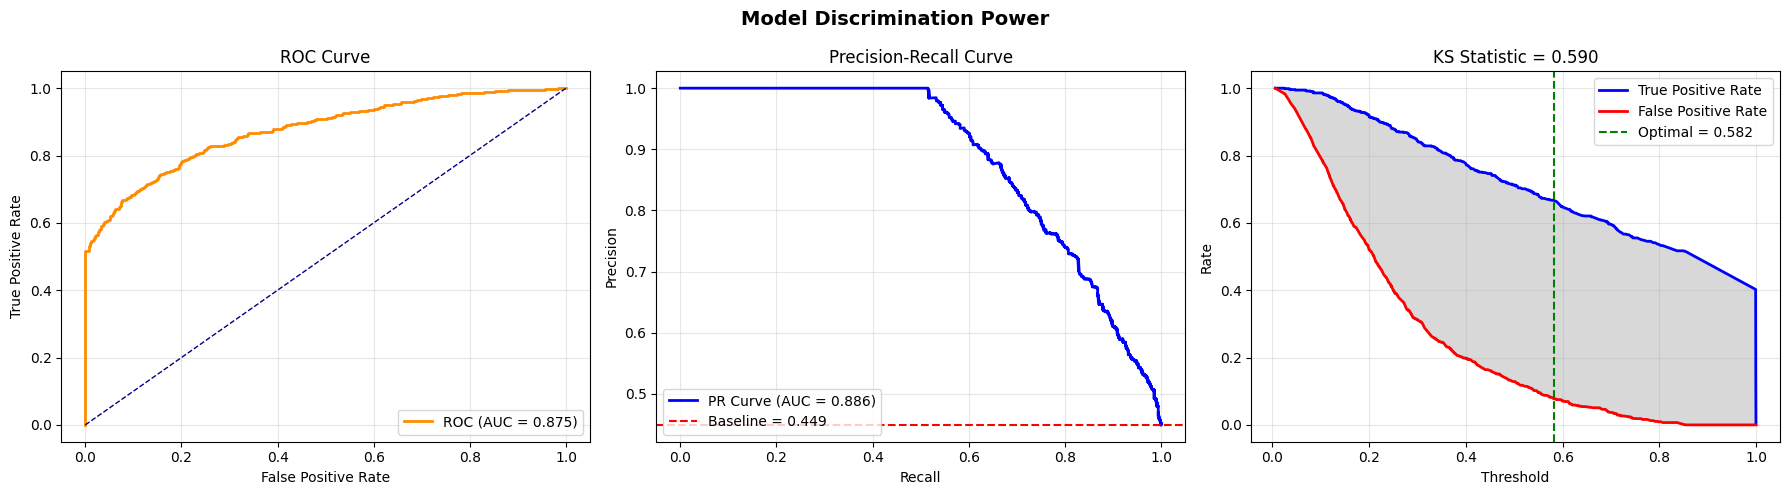

• ROC-AUC: 0.8755
• PR-AUC: 0.8856
• KS Statistic: 0.590 (EXCELLENT discrimination)
• Optimal Threshold: 0.582

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.999
Decile 10 mean prob: 0.054


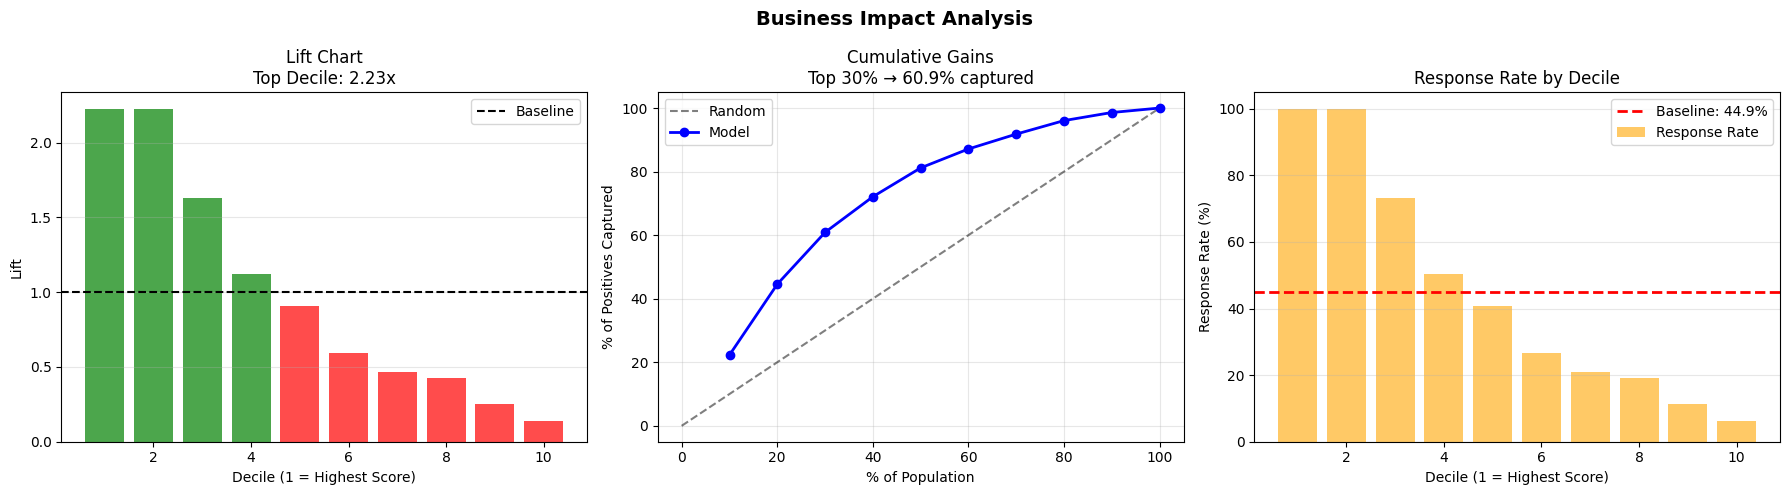

• Top Decile Lift: 0.14x
• Top 30% captures: 60.9% of positives
• Baseline response rate: 44.9%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


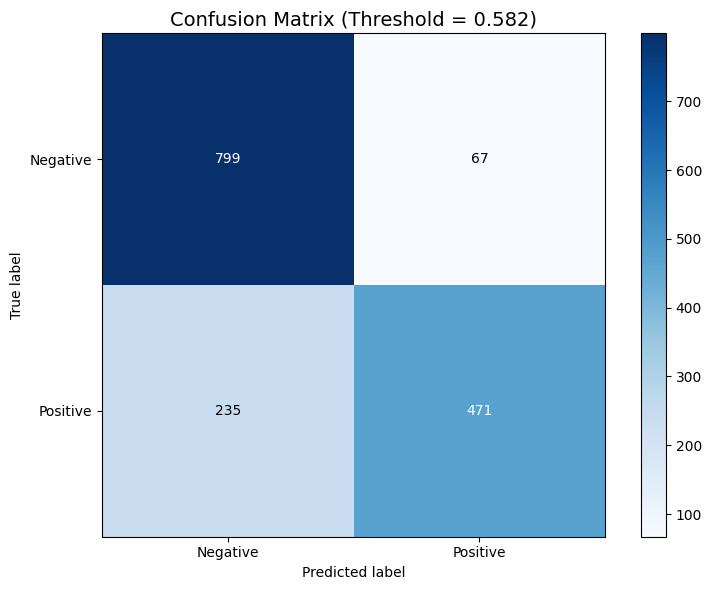

At threshold 0.582:
• Accuracy: 0.808
• Precision: 0.875
• Recall: 0.667
• F1-Score: 0.757
• True Positives: 471
• False Positives: 67
• True Negatives: 799
• False Negatives: 235

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.590 (EXCELLENT discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.14x better than random
   Coverage: Top 30% → 60.9% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8755 (Excellent if >0.8)
   PR-AUC: 0.8856 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.582
   Precision at threshold: 0.875
   Recall at threshold: 0.667

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
178      quote_consistency_score    0.189584
100      avg_days_between_quotes    0.101805
154              engagement_days    0.022007
180    decision_efficiency_score    0.015450
250                  value_score    0.013410
175          brand_loyalty_score    0.012962
134               role_stability   

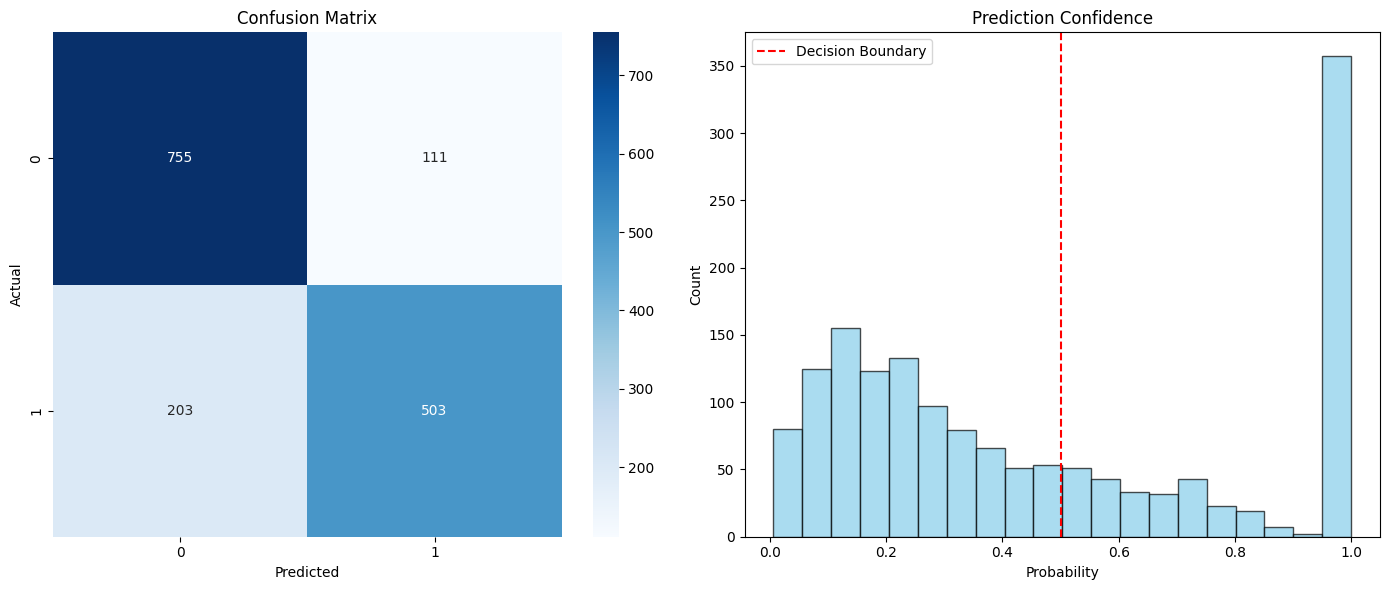

In [6]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])